<a href="https://colab.research.google.com/github/oszavla/Dirac-Schwarz/blob/main/Aproksimasi_Wentzel_Kramers_Brillouin_(WKB).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Kuantisasi Energi dan Lebar Keadaan Terikat


In [8]:
import numpy as np
import pandas as pd
from IPython.display import display

# Parameter Kuantum dan Sistem
kappas = [-10, -9, -8, -7, -6, -5, -4, -3, -2, -1, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
# kappas = [-5, -4, -3, -2, -1, 1, 2, 3, 4, 5]
# kappas = range(10**16,10**16+21)
N_r_values = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
# N_r_values = range(10**16,10**16+21)
alpha_prime = 1
alpha = 1.0  # Parameter untuk horizon (rho_0 = 2*alpha). Sesuaikan jika alpha berbeda dengan alpha'

# Konstanta Fisika (SI)
hbar = 1.054571817e-34    # J.s
m0 = 9.1093837e-31        # kg (massa elektron)
c = 299792458.0           # m/s
hbar_over_m0c2 = hbar / (m0 * c**2) # Faktor konversi ke sekon

# Inisialisasi dictionary untuk menyimpan data
epsilon_data = {k: [] for k in kappas}
T_data = {k: [] for k in kappas}
Gamma_data = {k: [] for k in kappas}
tau_data = {k: [] for k in kappas}
# allowed maximum principal quantum number n
N_MAX = abs(max(kappas))
for k in kappas:
    for n_r in N_r_values:
        # principal quantum number
        n = n_r + abs(k)
        if n > N_MAX:
          epsilon = np.nan
        elif n_r == 0 and k > 0:
            epsilon = np.nan
        else:
            term = 1 - ((alpha_prime / (n_r + np.abs(k) + 0.5))**2)
            epsilon = np.sqrt(term) if term >= 0 else np.nan

        # restored energy eigen value
        epsilon_data[k].append(epsilon)

        # Hitung T, Gamma, dan Tau jika epsilon valid
        if not np.isnan(epsilon) and epsilon > 0:
            sigma = 1 - epsilon**2
            kappa_abs = np.abs(k)

            # Hitung term di dalam akar untuk titik balik rho_1 dan rho_2
            term_rho = 1 - (sigma * kappa_abs**2) / (alpha_prime**2)

            if term_rho < 0:
                T, Gamma, tau = np.nan, np.nan, np.nan
            else:
                rho_1 = (alpha_prime / sigma) * (1 - np.sqrt(term_rho))
                rho_2 = (alpha_prime / sigma) * (1 + np.sqrt(term_rho))

                rho_0 = 2 * alpha
                bar_rho = (rho_0 + rho_1) / 2.0

                # Syarat tunneling: titik balik rho_1 harus di luar horizon rho_0
                if rho_1 <= rho_0 or bar_rho <= 2 * alpha:
                    T, Gamma, tau = np.nan, np.nan, np.nan
                else:
                    # Koefisien Transmisi (T = e^{-2\gamma})
                    exponent = -(np.pi * np.sqrt(sigma) / 4.0) * ((rho_1 - rho_0)**2) / (np.sqrt(bar_rho) * (bar_rho - 2 * alpha))
                    T = np.exp(exponent)

                    # Laju peluruhan (Gamma_n_rho)
                    Gamma = (sigma**(1.5) / (2 * np.pi * alpha_prime * epsilon)) * T

                    # Waktu Hidup (Tau) dalam sekon
                    tau = (1.0 / Gamma) * hbar_over_m0c2
        else:
            T, Gamma, tau = np.nan, np.nan, np.nan

        T_data[k].append(T)
        Gamma_data[k].append(Gamma)
        tau_data[k].append(tau)

# Fungsi bantuan untuk merender DataFrame
def render_table(data_dict, title, fmt):
    print(f"\n{'-'*15} {title} {'-'*15}")
    df = pd.DataFrame.from_dict(data_dict, orient='index', columns=[f'n_r={n_r}' for n_r in N_r_values])
    df.index.name = 'κ'
    display(df.style.format(fmt, na_rep="N/A").background_gradient(cmap='viridis', axis=None))

# Render semua tabel
render_table(epsilon_data, "ALLOWED ENERGY (E/m_0c^2)", "{:.6f}")
render_table(T_data, "TRANSMISSION COEFFICIENT (T)", "{:.6e}")
render_table(Gamma_data, "DECAY RATE (Γ)", "{:.6e}")
render_table(tau_data, "LIFETIME (τ) in seconds", "{:.6e}")


--------------- ALLOWED ENERGY (E/m_0c^2) ---------------


,n_r=0,n_r=1,n_r=2,n_r=3,n_r=4,n_r=5,n_r=6,n_r=7,n_r=8,n_r=9,n_r=10
κ,,,,,,,,,,,
-10,0.995455,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
-9,0.994444,0.995455,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
-8,0.993055,0.994444,0.995455,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
-7,0.991071,0.993055,0.994444,0.995455,N/A,N/A,N/A,N/A,N/A,N/A,N/A
-6,0.988095,0.991071,0.993055,0.994444,0.995455,N/A,N/A,N/A,N/A,N/A,N/A
-5,0.983332,0.988095,0.991071,0.993055,0.994444,0.995455,N/A,N/A,N/A,N/A,N/A
-4,0.974996,0.983332,0.988095,0.991071,0.993055,0.994444,0.995455,N/A,N/A,N/A,N/A
-3,0.958315,0.974996,0.983332,0.988095,0.991071,0.993055,0.994444,0.995455,N/A,N/A,N/A
-2,0.916515,0.958315,0.974996,0.983332,0.988095,0.991071,0.993055,0.994444,0.995455,N/A,N/A



--------------- TRANSMISSION COEFFICIENT (T) ---------------


,n_r=0,n_r=1,n_r=2,n_r=3,n_r=4,n_r=5,n_r=6,n_r=7,n_r=8,n_r=9,n_r=10
κ,,,,,,,,,,,
-10,1.685304e-01,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
-9,1.748626e-01,2.317803e-01,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
-8,1.832559e-01,2.461222e-01,2.953320e-01,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
-7,1.949264e-01,2.655187e-01,3.199749e-01,3.657089e-01,N/A,N/A,N/A,N/A,N/A,N/A,N/A
-6,2.122313e-01,2.932537e-01,3.542566e-01,4.043268e-01,4.467122e-01,N/A,N/A,N/A,N/A,N/A,N/A
-5,2.403068e-01,3.360592e-01,4.051678e-01,4.598994e-01,5.048665e-01,5.426563e-01,N/A,N/A,N/A,N/A,N/A
-4,2.923463e-01,4.097097e-01,4.879168e-01,5.462533e-01,5.920019e-01,6.290419e-01,6.597330e-01,N/A,N/A,N/A,N/A
-3,4.116769e-01,5.585106e-01,6.405339e-01,6.950646e-01,7.344782e-01,7.644991e-01,7.882193e-01,8.074805e-01,N/A,N/A,N/A
-2,8.110387e-01,9.407880e-01,9.735891e-01,9.859101e-01,9.915917e-01,9.945781e-01,9.962991e-01,9.973609e-01,9.980518e-01,N/A,N/A



--------------- DECAY RATE (Γ) ---------------


,n_r=0,n_r=1,n_r=2,n_r=3,n_r=4,n_r=5,n_r=6,n_r=7,n_r=8,n_r=9,n_r=10
κ,,,,,,,,,,,
-10,2.327604e-05,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
-9,3.264117e-05,3.201160e-05,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
-8,4.782420e-05,4.594303e-05,4.078883e-05,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
-7,7.419971e-05,6.929230e-05,5.972892e-05,5.050872e-05,N/A,N/A,N/A,N/A,N/A,N/A,N/A
-6,1.244775e-04,1.116285e-04,9.245020e-05,7.547470e-05,6.169623e-05,N/A,N/A,N/A,N/A,N/A,N/A
-5,2.337749e-04,1.971048e-04,1.542291e-04,1.200197e-04,9.424218e-05,7.494724e-05,N/A,N/A,N/A,N/A,N/A
-4,5.236937e-04,3.985731e-04,2.861720e-04,2.079340e-04,1.544945e-04,1.174217e-04,9.111692e-05,N/A,N/A,N/A,N/A
-3,1.594646e-03,1.000486e-03,6.231233e-04,4.076680e-04,2.795828e-04,1.995110e-04,1.471350e-04,1.115226e-04,N/A,N/A,N/A
-2,9.013678e-03,3.644178e-03,1.744036e-03,9.591116e-04,5.815865e-04,3.785911e-04,2.600037e-04,1.861749e-04,1.378427e-04,N/A,N/A



--------------- LIFETIME (τ) in seconds ---------------


,n_r=0,n_r=1,n_r=2,n_r=3,n_r=4,n_r=5,n_r=6,n_r=7,n_r=8,n_r=9,n_r=10
κ,,,,,,,,,,,
-10,5.533968e-17,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
-9,3.946209e-17,4.023818e-17,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
-8,2.693383e-17,2.803665e-17,3.157944e-17,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
-7,1.735975e-17,1.858920e-17,2.156558e-17,2.550230e-17,N/A,N/A,N/A,N/A,N/A,N/A,N/A
-6,1.034796e-17,1.153907e-17,1.393278e-17,1.706650e-17,2.087791e-17,N/A,N/A,N/A,N/A,N/A,N/A
-5,5.509953e-18,6.535045e-18,8.351785e-18,1.073231e-17,1.366786e-17,1.718660e-17,N/A,N/A,N/A,N/A,N/A
-4,2.459622e-18,3.231750e-18,4.501099e-18,6.194700e-18,8.337442e-18,1.096977e-17,1.413666e-17,N/A,N/A,N/A,N/A
-3,8.077584e-19,1.287462e-18,2.067149e-18,3.159651e-18,4.607182e-18,6.456229e-18,8.754470e-18,1.155002e-17,N/A,N/A,N/A
-2,1.429038e-19,3.534648e-19,7.385677e-19,1.343002e-18,2.214784e-18,3.402322e-18,4.954116e-18,6.918702e-18,9.344625e-18,N/A,N/A


In [7]:
import numpy as np
import pandas as pd
from IPython.display import display

# Physical Parameters (Scalar Coupling)
alpha_prime = 1

data = []

# Iterate through principal quantum number n from 1 to 4
for n in range(1, 11):

    # Generate kappas for the given n: -1, 1, -2, 2, ..., -n
    kappas_for_n = []
    for abs_k in range(1, n + 1):
        kappas_for_n.append(-abs_k)
        if abs_k < n:
            kappas_for_n.append(abs_k)

    for k in kappas_for_n:
        n_r = n - abs(k) # Radial quantum number

        # Orbital angular momentum (l)
        if k < 0:
            l = -k - 1
        else:
            l = k

        # Total angular momentum (j = |k| - 1/2)
        j_num = 2 * abs(k) - 1
        j_str = f"{j_num}/2"

        # Spectroscopic Notation Generation
        l_letters = ['S', 'P', 'D', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N']
        l_char = l_letters[l]
        notasi = f"${n} {l_char}_{{{j_str}}}$"

        # --- EXACT SOMMERFELD FORMULA (Scalar Coupling in Schwarzschild Gervitational Field) ---
        gamma_arg = k**2 #+ alpha_prime**2
        gamma = np.sqrt(gamma_arg)
        denominator = n_r + gamma +1/2

        # Calculate energy ratio: E / m_0 c^2
        term = 1 - (alpha_prime / denominator)**2
        epsilon = np.sqrt(term)

        # Append row data
        data.append({
            "Notasi": notasi,
            "$n$": n,
            "$l$": l,
            "$j$": j_str,
            "$n_r$": n_r,
            "$\\kappa$": k,
            "$E / m_0 c^2$": epsilon
        })

# Create DataFrame
df_epsilon = pd.DataFrame(data)

# Format the dimensionless energy column to 6 decimal places
df_formatted = df_epsilon.copy()
df_formatted['$E / m_0 c^2$'] = df_formatted['$E / m_0 c^2$'].map('{:.10f}'.format)

# Display the table in Jupyter with the index hidden
print("Exact Dirac Energy Eigenvalues (E/mc^2) - Scalar Coupling:")
display(df_formatted.style.hide(axis="index"))

# ---------------------------------------------------------
# OPTIONAL: Automatically generate the LaTeX code
# ---------------------------------------------------------
latex_output = df_formatted.style.hide(axis="index").to_latex(
    column_format=">{\\centering\\arraybackslash}p{2.15cm}cccccc",
    hrules=True
)

# Print LaTeX wrapper
print("\n\\begin{table}[H]")
print("\\begin{center}")
print("\\caption{Klasifikasi keadaan terikat fermion Dirac dengan parameter skalar ($\\alpha' = 1$)} hasil dari aproksimasi WKB")
print("\\small\\setlength{\\tabcolsep}{4pt}")
print(latex_output, end="")
print("\\end{center}\\label{tabel_energi_skalar_WKB}")
print("\\end{table}")

Exact Dirac Energy Eigenvalues (E/mc^2) - Scalar Coupling:


Notasi,$n$,$l$,$j$,$n_r$,$\kappa$,$E / m_0 c^2$
$1 S_{1/2}$,1,0,1/2,0,-1,0.7453559925
$2 S_{1/2}$,2,0,1/2,1,-1,0.9165151390
$2 P_{1/2}$,2,1,1/2,1,1,0.9165151390
$2 P_{3/2}$,2,1,3/2,0,-2,0.9165151390
$3 S_{1/2}$,3,0,1/2,2,-1,0.9583148475
$3 P_{1/2}$,3,1,1/2,2,1,0.9583148475
$3 P_{3/2}$,3,1,3/2,1,-2,0.9583148475
$3 D_{3/2}$,3,2,3/2,1,2,0.9583148475
$3 D_{5/2}$,3,2,5/2,0,-3,0.9583148475
$4 S_{1/2}$,4,0,1/2,3,-1,0.9749960430



\begin{table}[H]
\begin{center}
\caption{Klasifikasi keadaan terikat fermion Dirac dengan parameter skalar ($\alpha' = 1$)} hasil dari aproksimasi WKB
\small\setlength{\tabcolsep}{4pt}
\begin{tabular}{>{\centering\arraybackslash}p{2.15cm}cccccc}
\toprule
Notasi & $n$ & $l$ & $j$ & $n_r$ & $\kappa$ & $E / m_0 c^2$ \\
\midrule
$1 S_{1/2}$ & 1 & 0 & 1/2 & 0 & -1 & 0.7453559925 \\
$2 S_{1/2}$ & 2 & 0 & 1/2 & 1 & -1 & 0.9165151390 \\
$2 P_{1/2}$ & 2 & 1 & 1/2 & 1 & 1 & 0.9165151390 \\
$2 P_{3/2}$ & 2 & 1 & 3/2 & 0 & -2 & 0.9165151390 \\
$3 S_{1/2}$ & 3 & 0 & 1/2 & 2 & -1 & 0.9583148475 \\
$3 P_{1/2}$ & 3 & 1 & 1/2 & 2 & 1 & 0.9583148475 \\
$3 P_{3/2}$ & 3 & 1 & 3/2 & 1 & -2 & 0.9583148475 \\
$3 D_{3/2}$ & 3 & 2 & 3/2 & 1 & 2 & 0.9583148475 \\
$3 D_{5/2}$ & 3 & 2 & 5/2 & 0 & -3 & 0.9583148475 \\
$4 S_{1/2}$ & 4 & 0 & 1/2 & 3 & -1 & 0.9749960430 \\
$4 P_{1/2}$ & 4 & 1 & 1/2 & 3 & 1 & 0.9749960430 \\
$4 P_{3/2}$ & 4 & 1 & 3/2 & 2 & -2 & 0.9749960430 \\
$4 D_{3/2}$ & 4 & 2 & 3/2 & 2 & 2 & 0.97

## Koefisien Transmisi pada beberapa rentang nilai energi


/tmp/ipykernel_451/2645884014.py:29: RuntimeWarning: divide by zero encountered in scalar divide
  rho_1 = (alpha_prime / sigma) * (1 - np.sqrt(term_rho))
/tmp/ipykernel_451/2645884014.py:29: RuntimeWarning: invalid value encountered in scalar multiply
  rho_1 = (alpha_prime / sigma) * (1 - np.sqrt(term_rho))


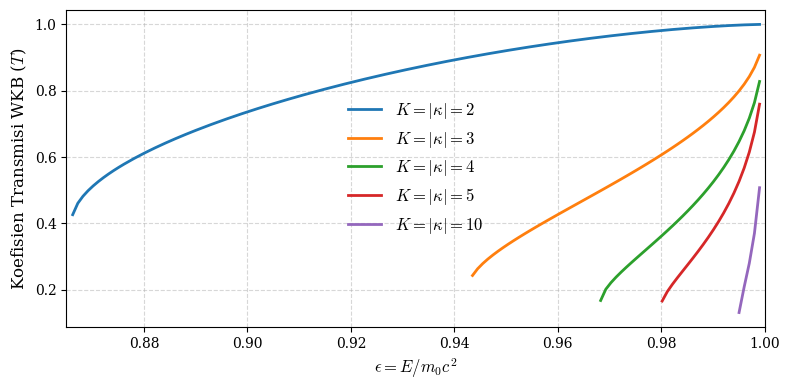

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# Font Style
plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'DejaVu Serif'
plt.rcParams['mathtext.fontset'] = 'cm'
# Parameter Sistem
alpha = 1.0       # Terkait horizon rho_0 = 2*alpha
alpha_prime = 1.0 # Kopling sistem
kappa_values = [2, 3, 4, 5, 10] # Menggunakan K yang lebih besar agar rho_1 berada di luar horizon

# Rentang energi epsilon kontinu dari 0.01 hingga 0.999 (mendekati 1)
epsilon_continuum = np.linspace(0.01, 1, 1000)

plt.figure(figsize=(8, 4))

for K in kappa_values:
    T_values = []
    valid_epsilons = []

    for eps in epsilon_continuum:
        sigma = 1 - eps**2

        # Cek syarat akar real untuk titik balik
        term_rho = 1 - (sigma * K**2) / (alpha_prime**2)
        if term_rho < 0:
            continue # Abaikan jika titik balik kompleks

        rho_1 = (alpha_prime / sigma) * (1 - np.sqrt(term_rho))
        rho_0 = 2 * alpha
        bar_rho = (rho_0 + rho_1) / 2.0

        # Syarat tunneling: titik balik rho_1 harus di luar horizon rho_0
        # dan bar_rho (titik tengah aproksimasi) harus masuk akal
        if rho_1 > rho_0 and bar_rho > rho_0:
            exponent = -(np.pi * np.sqrt(sigma) / 4.0) * ((rho_1 - rho_0)**2) / (np.sqrt(bar_rho) * (bar_rho - rho_0))
            T = np.exp(exponent)

            valid_epsilons.append(eps)
            T_values.append(T)

    # Plot kurva jika ada data yang valid
    if valid_epsilons:
        plt.plot(valid_epsilons, T_values, label=f'$K = |\\kappa| = {K}$', linewidth=2)

# Mengatur tampilan Plot
#plt.yscale('log') # Skala logaritmik cocok karena T bervariasi secara eksponensial
#plt.title('Koefisien Transmisi ($T$) vs Energi Kuasi-Terikat ($\\epsilon$)', fontsize=14)
plt.xlabel(r'$\epsilon = E/m_0c^2$', fontsize=12)
plt.ylabel('Koefisien Transmisi WKB ($T$)', fontsize=12)
plt.xlim(0.865, 1)
#plt.ylim(0.1, 1)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(fontsize=12, frameon=False)
plt.tight_layout()

# Tampilkan plot
plt.show()

## Rentang energi jika $\alpha'$ semakin besar

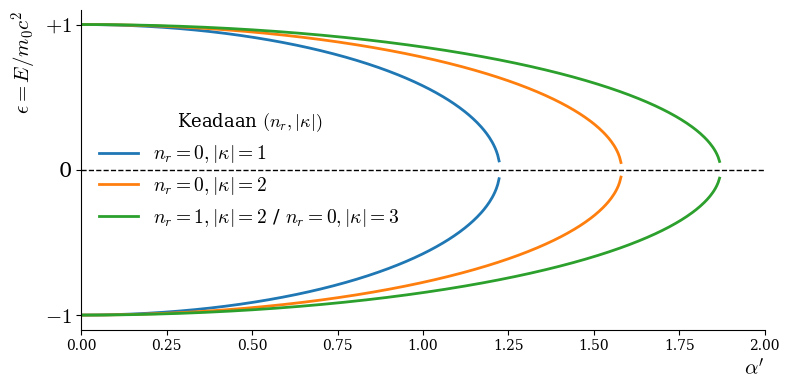

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Generate alpha_prime values
# Extended slightly past sqrt(1.5) to show the termination of the lowest state
alpha_prime = np.linspace(0, 2.0, 500)

# Define the new energy function
def calc_epsilon(alpha, n_r, kappa_abs):
    denominator = n_r + kappa_abs + 0.5
    # Find valid domain where the expression inside the sqrt is non-negative
    valid = (alpha**2) <= denominator

    # Initialize array with NaNs to prevent plotting imaginary values
    E = np.full_like(alpha, np.nan)
    E[valid] = np.sqrt(1 - (alpha[valid]**2) / denominator)
    return E

# Set up the plot
fig, ax = plt.subplots(figsize=(8, 4))

# Define the allowed states based on n_r < |\kappa|
states = [
    {"n_r": 0, "kappa": 1, "label": r"$n_r=0, |\kappa|=1$", "color": "#1f77b4"},
    {"n_r": 0, "kappa": 2, "label": r"$n_r=0, |\kappa|=2$", "color": "#ff7f0e"},
    # We combine (1,2) and (0,3) in the legend since they are mathematically degenerate here
    {"n_r": 1, "kappa": 2, "label": r"$n_r=1, |\kappa|=2$ / $n_r=0, |\kappa|=3$", "color": "#2ca02c"},
]

# Plot each state
for state in states:
    E_pos = calc_epsilon(alpha_prime, state["n_r"], state["kappa"])

    # Positive branch
    ax.plot(alpha_prime, E_pos, label=state["label"], color=state["color"], linewidth=2)
    # Negative branch
    ax.plot(alpha_prime, -E_pos, color=state["color"], linewidth=2)

# Formatting the axes and limits
ax.set_xlim(0, max(alpha_prime))
ax.set_ylim(-1.1, 1.1)
ax.set_xlabel(r'$\alpha^\prime$', fontsize=15, loc='right')
ax.set_ylabel(r'$\epsilon = E/m_0c^2$', fontsize=15, loc='top')
ax.set_yticks([-1, 0, 1])
ax.set_yticklabels([r'$-1$', '0', r'$+1$'], fontsize=15)

# Spine formatting for standard physics textbook look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.axhline(0, color='black', linewidth=1, linestyle='--')

# Add legend
ax.legend(title=r"Keadaan $(n_r, |\kappa|)$", loc='center left', frameon=False, fontsize=14, title_fontsize=13)

plt.tight_layout()
plt.show()

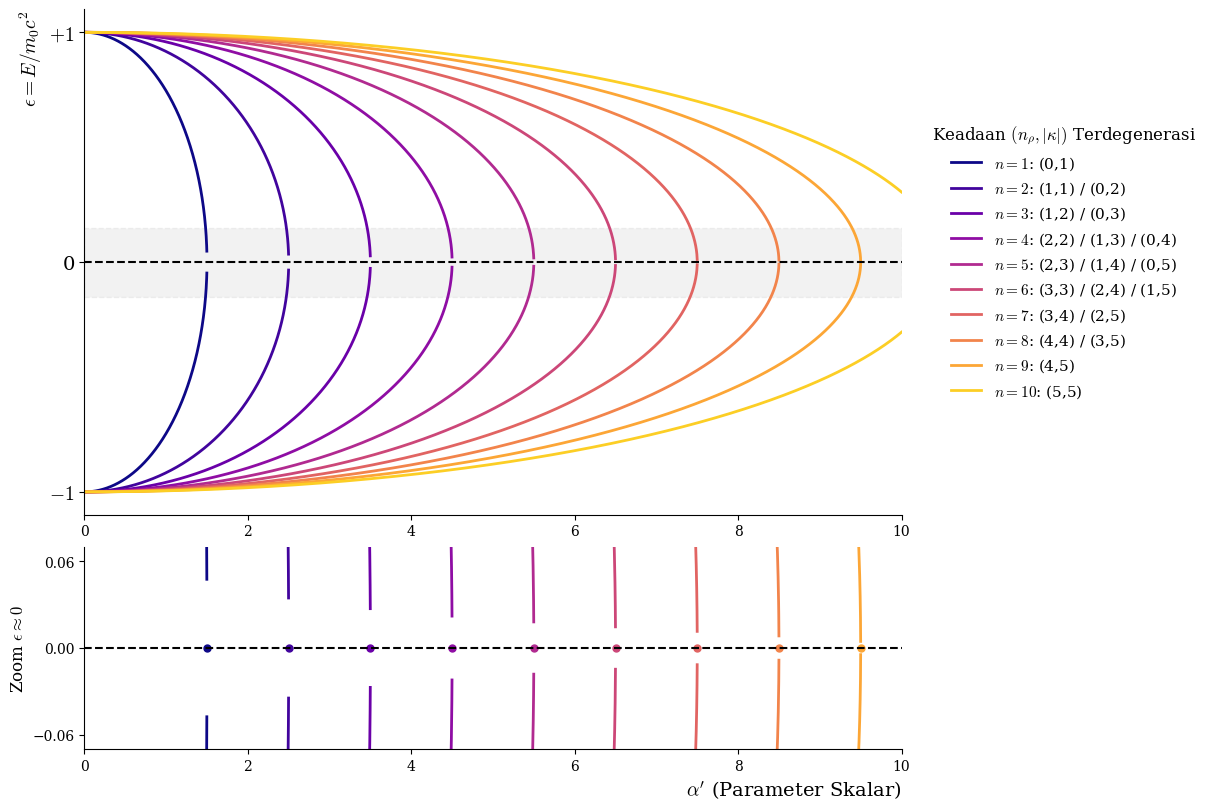

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.gridspec as gridspec
from matplotlib.patches import Rectangle
# Font Style
plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'DejaVu Serif'
plt.rcParams['mathtext.fontset'] = 'cm'
# Perluas rentang alpha_prime hingga 11 untuk mengakomodasi N=10
# Resolusi ditingkatkan (5000) agar mendekati titik nol secara lebih mulus
alpha_prime = np.linspace(0, 10.0, 5000)

kappas_abs = [1, 2, 3, 4, 5]
degenerate_states = {}

for k in kappas_abs:
    for n_r in range(k + 1):
        N_sum = n_r + k
        denom = N_sum + 0.5
        label_str = f"({n_r},{k})"
        if denom not in degenerate_states:
            degenerate_states[denom] = []
        degenerate_states[denom].append(label_str)

def calc_epsilon(alpha, denom):
    valid = (alpha**2) <= (denom**2)
    E = np.full_like(alpha, np.nan)
    E[valid] = np.sqrt(1 - (alpha[valid]**2) / (denom**2))
    return E

# SOLUSI WARNING: Gunakan constrained_layout=True sejak awal pembuatan figure
fig = plt.figure(figsize=(12, 8), constrained_layout=True)

# Parameter hspace bisa dihilangkan karena constrained_layout akan mengaturnya otomatis
gs = gridspec.GridSpec(2, 1, height_ratios=[2.5, 1], figure=fig)

ax_main = fig.add_subplot(gs[0])   # Plot Utama
ax_inset = fig.add_subplot(gs[1])  # Plot Inset (Perbesaran)

sorted_denoms = sorted(degenerate_states.keys())
colors = cm.plasma(np.linspace(0, 0.9, len(sorted_denoms)))

for idx, denom in enumerate(sorted_denoms):
    states_list = degenerate_states[denom]
    if len(states_list) > 4:
        label_display = " / ".join(states_list[:4]) + ", dsb"
    else:
        label_display = " / ".join(states_list)

    N_int = int(denom - 0.5)
    label = f"$n={N_int}$: {label_display}"

    E_pos = calc_epsilon(alpha_prime, denom)

    # 1. Gambar pada Plot Utama
    ax_main.plot(alpha_prime, E_pos, label=label, color=colors[idx], linewidth=2)
    ax_main.plot(alpha_prime, -E_pos, color=colors[idx], linewidth=2)

    # 2. Gambar pada Plot Inset
    ax_inset.plot(alpha_prime, E_pos, color=colors[idx], linewidth=2)
    ax_inset.plot(alpha_prime, -E_pos, color=colors[idx], linewidth=2)

    # Tambahkan penanda (dot) di lokasi pasti cut-off
    ax_inset.plot(denom, 0, marker='o', color=colors[idx], markersize=5)

### FORMATTING PLOT UTAMA ###
ax_main.set_xlim(0, max(alpha_prime))
ax_main.set_ylim(-1.1, 1.1)
ax_main.set_ylabel(r'$\epsilon = E/m_0c^2$', fontsize=14, loc='top')
ax_main.set_yticks([-1, 0, 1])
ax_main.set_yticklabels([r'$-1$', '0', r'$+1$'], fontsize=14)
ax_main.spines['top'].set_visible(False)
ax_main.spines['right'].set_visible(False)
ax_main.axhline(0, color='black', linewidth=1.5, linestyle='--')

# Letakkan Legend di luar grafik utama
ax_main.legend(title=r"Keadaan $(n_\rho, |\kappa|)$ Terdegenerasi",
               bbox_to_anchor=(1.02, 0.5), loc='center left',
               frameon=False, fontsize=11, title_fontsize=12)

# Tambahkan kotak pembatas bayangan di plot utama
rect = Rectangle((0, -0.15), max(alpha_prime), 0.3, linewidth=1,
                 edgecolor='gray', facecolor='gray', alpha=0.1, linestyle='--')
ax_main.add_patch(rect)

### FORMATTING PLOT INSET (PERBESARAN) ###
ax_inset.set_xlim(0, max(alpha_prime))
ax_inset.set_ylim(-0.07, 0.07)
ax_inset.set_xlabel(r'$\alpha^\prime$ (Parameter Skalar)', fontsize=14, loc='right')
ax_inset.set_ylabel(r'Zoom $\epsilon \approx 0$', fontsize=12)
ax_inset.set_yticks([-0.06, 0, 0.06])
ax_inset.spines['top'].set_visible(False)
ax_inset.spines['right'].set_visible(False)
ax_inset.axhline(0, color='black', linewidth=1.5, linestyle='--')

# plt.tight_layout() # Baris ini Dihapus agar tidak konflik dengan constrained_layout

plt.show()

### Konversi $\TeX$

In [6]:
import pandas as pd

# 1. Definisikan label kolom dan indeks
# N_r_values didapat dari kode sebelumnya: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
columns_labels = [f'$n_\\rho = {n}$' for n in N_r_values]

# 2. Buat DataFrame secara eksplisit untuk keempat besaran
df_epsilon = pd.DataFrame.from_dict(epsilon_data, orient='index', columns=columns_labels)
df_T = pd.DataFrame.from_dict(T_data, orient='index', columns=columns_labels)
df_Gamma = pd.DataFrame.from_dict(Gamma_data, orient='index', columns=columns_labels)
df_tau = pd.DataFrame.from_dict(tau_data, orient='index', columns=columns_labels)

# Set nama index (simbol kappa) untuk semua DataFrame
for df in [df_epsilon, df_T, df_Gamma, df_tau]:
    df.index.name = r'$\kappa$'

# 3. Buat fungsi generalator LaTeX agar tidak repot mengulang kode
def export_to_latex(df, caption, label, fmt):
    # Buat objek styler dengan format dan gradien warna
    styler = df.style.format(fmt, na_rep=" - ").background_gradient(cmap='viridis', axis=None)

    # Hasilkan string LaTeX
    latex_table_content = styler.to_latex(
        column_format="l" + "c" * len(df.columns),
        hrules=True,
        convert_css=True
    )

    # Wrapper Header dan Footer
    header = f"""\\begin{{table}}[H]
\\centering
\\caption{{{caption}}}
\\label{{{label}}}
\\resizebox{{\\textwidth}}{{!}}{{%
"""
    footer = r"""}
\end{table}"""

    return header + latex_table_content + footer

# 4. Hasilkan kode LaTeX (Silakan ganti/panggil sesuai kebutuhan Anda)
# Contoh 1: Tabel Energi Epsilon
latex_epsilon = export_to_latex(
    df=df_epsilon,
    caption=r"Nilai eigen energi $\epsilon=E/m_0c^2$ yang didapat dari Aproksimasi WKB",
    label="tab:epsilon_eigenvalues",
    fmt="{:.6f}"
)

# Contoh 2: Tabel Waktu Hidup (Lifetime)
latex_T = export_to_latex(
    df=df_T,
    caption=r"Koefisien transmisi fermion dari aproksimasi WKB akibat pengaruh potensial Dirac-Swarzschild",
    label="tab:KoefisienTransmisi",
    fmt="{:.6e}" # Gunakan format scientific notation untuk nilai yang sangat besar/kecil
)

latex_Gamma = export_to_latex(
    df=df_Gamma,
    caption=r"Laju peluruhan keeadaan terikat fermion, semakin tinggi nilainya, maka akan semakin cepat dia masuk ke dalam keadaan kontinum (tertelan oleh horizon)",
    label="tab:lifetime_tau",
    fmt="{:.6e}" # Gunakan format scientific notation untuk nilai yang sangat besar/kecil
)

latex_tau = export_to_latex(
    df=df_tau,
    caption=r"Waktu hidup (\textit{lifetime}) $\tau$ dalam hitungan sekon",
    label="tab:lifetime_tau",
    fmt="{:.6e}" # Gunakan format scientific notation untuk nilai yang sangat besar/kecil
)

# Cetak preambel (Hanya perlu dimasukkan sekali di dokumen LaTeX Anda)
print("--- COPY THIS INTO YOUR LATEX PREAMBLE ---")
print(r"\usepackage[table]{xcolor}")
print(r"\usepackage{booktabs}")
print(r"\usepackage{graphicx}")


print("\n--- COPY THIS INTO YOUR LATEX DOCUMENT ---")
print("-----------Energi-------------")
print(latex_epsilon)
print("-----------Koefisien Transmisi-------------")
print(latex_T)
print("-----------Laju Peluruhan-------------")
print(latex_Gamma)
print("-----------Waktu Hidup------------")
print(latex_tau)

--- COPY THIS INTO YOUR LATEX PREAMBLE ---
\usepackage[table]{xcolor}
\usepackage{booktabs}
\usepackage{graphicx}

--- COPY THIS INTO YOUR LATEX DOCUMENT ---
-----------Energi-------------
\begin{table}[H]
\centering
\caption{Nilai eigen energi $\epsilon=E/m_0c^2$ yang didapat dari Aproksimasi WKB}
\label{tab:epsilon_eigenvalues}
\resizebox{\textwidth}{!}{%
\begin{tabular}{lcccccc}
\toprule
 & $n_\rho = 0$ & $n_\rho = 1$ & $n_\rho = 2$ & $n_\rho = 3$ & $n_\rho = 4$ & $n_\rho = 5$ \\
$\kappa$ &  &  &  &  &  &  \\
\midrule
-5 & {\cellcolor[HTML]{FDE725}} \color[HTML]{000000} 0.983332 & {\cellcolor[HTML]{000000}} \color[HTML]{F1F1F1}  -  & {\cellcolor[HTML]{000000}} \color[HTML]{F1F1F1}  -  & {\cellcolor[HTML]{000000}} \color[HTML]{F1F1F1}  -  & {\cellcolor[HTML]{000000}} \color[HTML]{F1F1F1}  -  & {\cellcolor[HTML]{000000}} \color[HTML]{F1F1F1}  -  \\
-4 & {\cellcolor[HTML]{EAE51A}} \color[HTML]{000000} 0.974996 & {\cellcolor[HTML]{FDE725}} \color[HTML]{000000} 0.983332 & {\cellcolor[HTM